In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("C:/Users/Anand/Downloads/dataset1.csv")
df.head()

,Age,Balance,Tenure,Num_Products,Has_Credit_Card,Is_Active_Member,Estimated_Salary,Churn
0,56,4343,3,4,0,1,59279,0
1,69,14500,9,1,0,1,129787,0
2,46,54222,13,1,0,0,43888,1
3,32,30375,18,2,0,1,37630,1
4,60,10662,15,1,1,0,81063,0


In [3]:
print(df.corr())

                       Age   Balance    Tenure  Num_Products  Has_Credit_Card  \
Age               1.000000  0.010748  0.058338     -0.118222         0.007190   
Balance           0.010748  1.000000  0.034718      0.035978        -0.037428   
Tenure            0.058338  0.034718  1.000000      0.040823         0.004339   
Num_Products     -0.118222  0.035978  0.040823      1.000000        -0.005308   
Has_Credit_Card   0.007190 -0.037428  0.004339     -0.005308         1.000000   
Is_Active_Member  0.048821 -0.091128 -0.001644      0.044883         0.128066   
Estimated_Salary -0.060802  0.006736 -0.041121      0.019906         0.067305   
Churn            -0.035567  0.016988 -0.001759     -0.040855        -0.040001   

                  Is_Active_Member  Estimated_Salary     Churn  
Age                       0.048821         -0.060802 -0.035567  
Balance                  -0.091128          0.006736  0.016988  
Tenure                   -0.001644         -0.041121 -0.001759  
Num_Produc

In [4]:
print(df.isnull().sum())

Age                 0
Balance             0
Tenure              0
Num_Products        0
Has_Credit_Card     0
Is_Active_Member    0
Estimated_Salary    0
Churn               0
dtype: int64


In [5]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for col in df.columns:
    if df[col].dtype=="object":
        df[col]=le.fit_transform(df[col])
print(df.head())

   Age  Balance  Tenure  Num_Products  Has_Credit_Card  Is_Active_Member  \
0   56     4343       3             4                0                 1   
1   69    14500       9             1                0                 1   
2   46    54222      13             1                0                 0   
3   32    30375      18             2                0                 1   
4   60    10662      15             1                1                 0   

   Estimated_Salary  Churn  
0             59279      0  
1            129787      0  
2             43888      1  
3             37630      1  
4             81063      0  


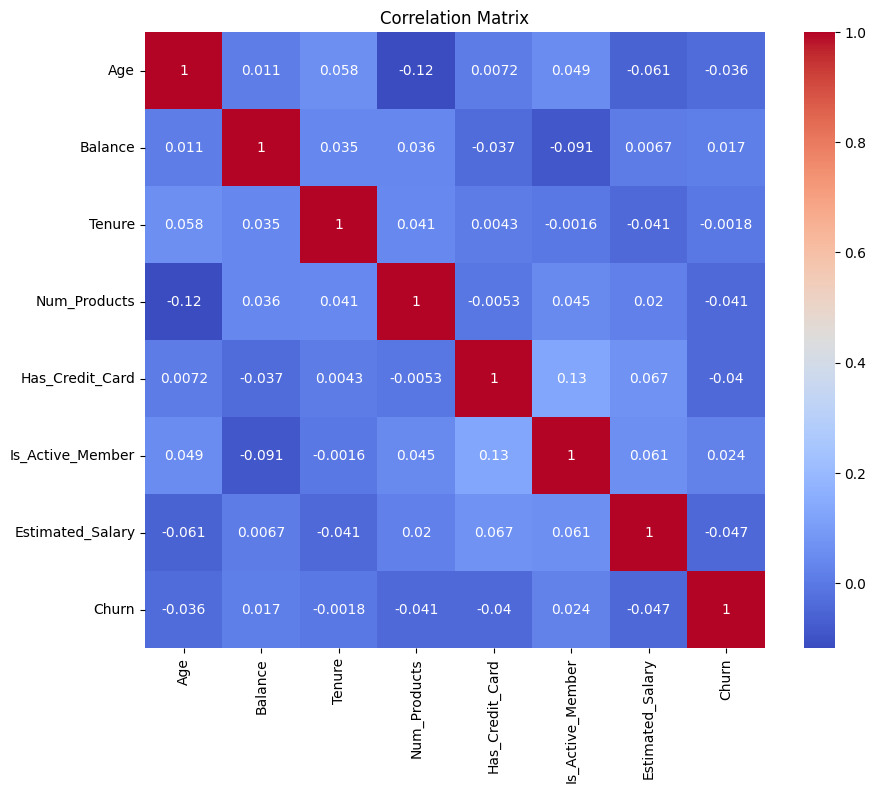

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True,cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [12]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df.drop('Churn', axis=1)

vif = pd.DataFrame()
vif["Feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i)
              for i in range(X.shape[1])]

print(vif)

            Feature       VIF
0               Age  6.292231
1           Balance  3.580918
2            Tenure  3.818340
3      Num_Products  4.740914
4   Has_Credit_Card  1.996293
5  Is_Active_Member  2.101265
6  Estimated_Salary  4.806918


In [11]:
pip install statsmodels

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.6 MB 893.5 kB/s eta 0:00:11
   --- ------------------------------------ 0.8/9.6 MB 938.2 kB/s eta 0:00:10
   ---- ----------------------------------- 1.0/9.6 MB 1.0 MB/s eta 0:00:09
   ----- ---------------------------------- 1.3/9.6 MB 1.1 MB/s eta 0:00:08
   ------ --------------------------------- 1.6/9.6 MB 1.1 MB/s eta 0:00:08
   ------- -------------------------------- 1.8/9.6 MB 1.1 MB/s eta 0:00:07
   -------- ------------------------------- 2.1/9.6 MB 1.1 MB/s eta 0:00:07
   --------- ------------------------------ 2.4/9.6 MB 1.1 MB/s eta 0:00:07
   ---------- ----------------------------- 2.6/9.6 MB 1.1 MB/s eta 0:00:07
   ------------ --------------------

In [13]:
X=df.drop("Churn",axis=1)
y=df["Churn"]

In [14]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

In [15]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(X_train,y_train)

C:\Users\Anand\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [16]:
y_pred_lr=lr.predict(X_test)

In [17]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred_lr)

0.49

In [18]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [19]:
y_pred_rf=rf.predict(X_test)

In [20]:
accuracy_score(y_test,y_pred_rf)

0.52

In [21]:
lr_accuracy=accuracy_score(y_test,y_pred_lr)
rf_accuracy=accuracy_score(y_test,y_pred_rf)
if lr_accuracy>rf_accuracy:
    print("Logistic Regression is better")
else:
    print("Random Forest Classifier is better")

Random Forest Classifier is better


            Feature  Importance
1           Balance    0.247606
6  Estimated_Salary    0.224778
0               Age    0.203547
2            Tenure    0.182457
3      Num_Products    0.072111
5  Is_Active_Member    0.035176
4   Has_Credit_Card    0.034324


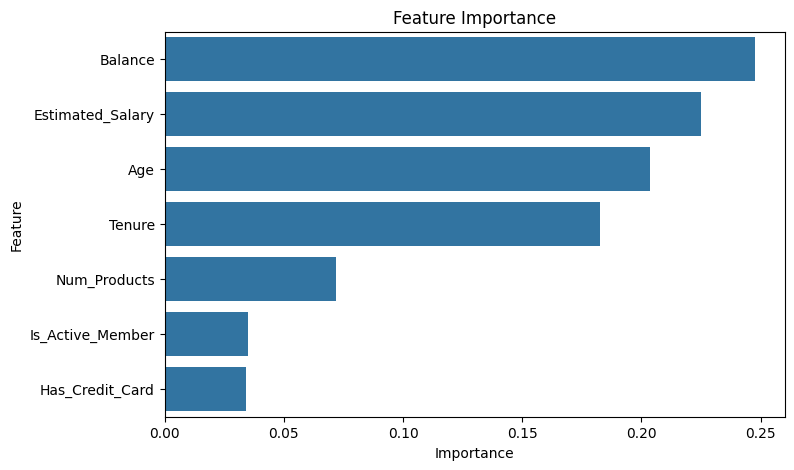

In [22]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

plt.figure(figsize=(8,5))
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)
plt.title("Feature Importance")
plt.show()

In [23]:
lr.coef_[0]

array([-1.36433570e-03,  3.98696275e-06,  7.05757750e-03, -1.05070525e-01,
       -1.42266266e-01,  1.22634208e-01, -1.19812647e-07])

In [24]:
coef=pd.DataFrame(
    {
        "Feature":X.columns,
        "Coefficient":lr.coef_[0]
    })


In [25]:
coef

,Feature,Coefficient
0,Age,-1.364336e-03
1,Balance,3.986963e-06
2,Tenure,7.057578e-03
3,Num_Products,-1.050705e-01
4,Has_Credit_Card,-1.422663e-01
5,Is_Active_Member,1.226342e-01
6,Estimated_Salary,-1.198126e-07


In [26]:
print(coef.sort_values(by="Coefficient",ascending=False))

            Feature   Coefficient
5  Is_Active_Member  1.226342e-01
2            Tenure  7.057578e-03
1           Balance  3.986963e-06
6  Estimated_Salary -1.198126e-07
0               Age -1.364336e-03
3      Num_Products -1.050705e-01
4   Has_Credit_Card -1.422663e-01
